# 02 — Explore Filtered Data

EDA on the gold/silver articles filtered from American Stories.
Goals: understand the volume, distribution, and content of our filtered articles
before running stance detection.

**Input**: `data/american_stories/filtered_articles.parquet`

In [1]:
import sys
sys.path.insert(0, "..")

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [ ]:
df = pd.read_parquet("../data/american_stories/filtered_articles.parquet")

# Parse matched_keywords: ensure it's always a list of keyword strings.
# Parquet may store it as pipe-delimited strings or as native lists.
df['matched_keywords'] = df['matched_keywords'].apply(
    lambda x: x.split('|') if isinstance(x, str) else (x if isinstance(x, list) else [])
)

print(f"Total articles: {len(df):,}")
print(f"Sample keywords: {df['matched_keywords'].iloc[0]}")
print(f"Type check: {type(df['matched_keywords'].iloc[0])}")
df.head()

## Basic Statistics

Article length (characters):
count    56355.000000
mean      2187.230716
std       1848.685729
min        100.000000
25%        659.000000
50%       1617.000000
75%       3259.000000
max      11022.000000
Name: article_length, dtype: float64


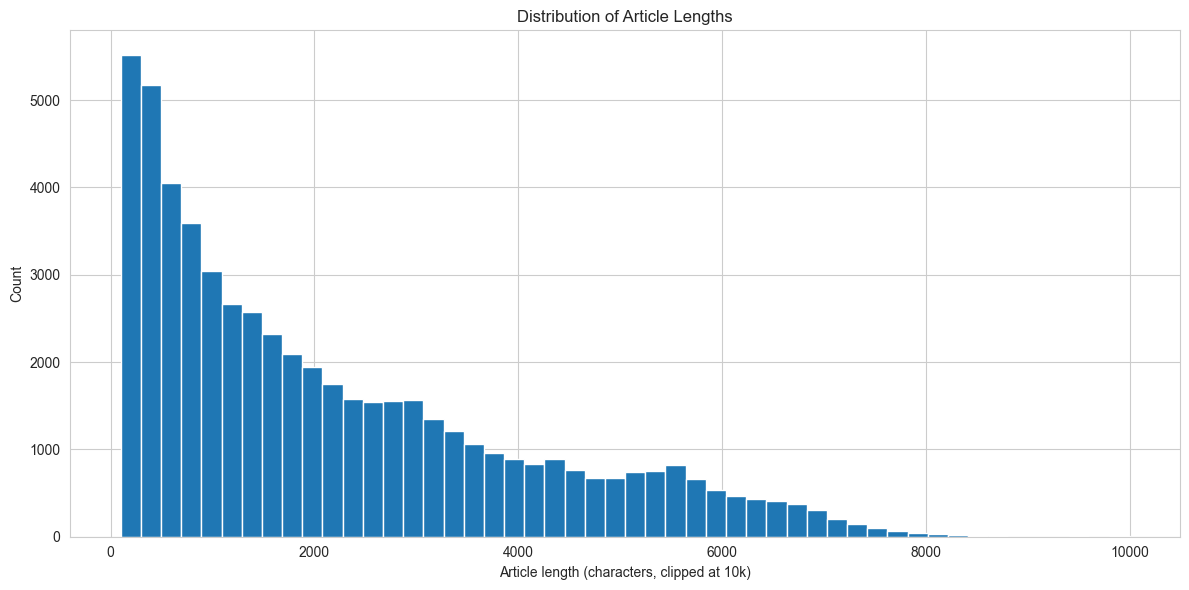

In [3]:
# Article length distribution
df['article_length'] = df['article'].str.len()

print("Article length (characters):")
print(df['article_length'].describe())

fig, ax = plt.subplots()
df['article_length'].clip(upper=10000).hist(bins=50, ax=ax)
ax.set_xlabel('Article length (characters, clipped at 10k)')
ax.set_ylabel('Count')
ax.set_title('Distribution of Article Lengths')
plt.tight_layout()
plt.show()

In [4]:
# Number of keyword matches per article
df['n_keywords'] = df['matched_keywords'].apply(len)

print("Keywords matched per article:")
print(df['n_keywords'].value_counts().sort_index())

Keywords matched per article:
n_keywords
7        477
8       1510
9        748
10      1411
11     15578
       ...  
101        1
102        3
107        1
109        1
119        1
Name: count, Length: 97, dtype: int64


## Articles Over Time

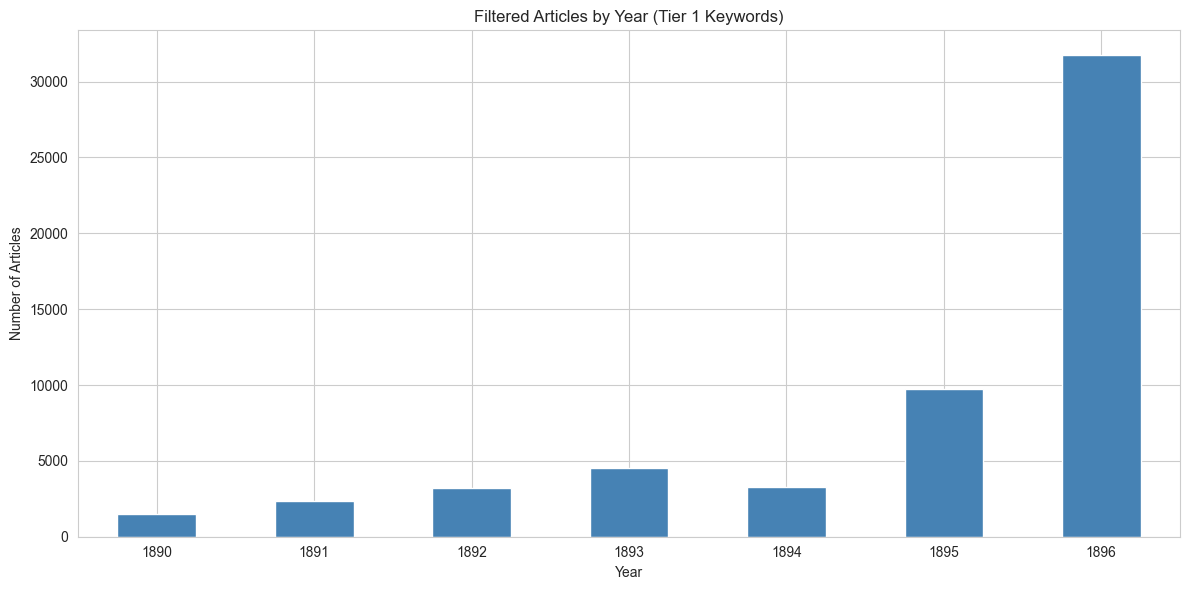

In [5]:
# Articles per year
year_counts = df['year'].value_counts().sort_index()

fig, ax = plt.subplots()
year_counts.plot(kind='bar', ax=ax, color='steelblue')
ax.set_xlabel('Year')
ax.set_ylabel('Number of Articles')
ax.set_title('Filtered Articles by Year (Tier 1 Keywords)')
ax.set_xticklabels(year_counts.index, rotation=0)
plt.tight_layout()
plt.show()

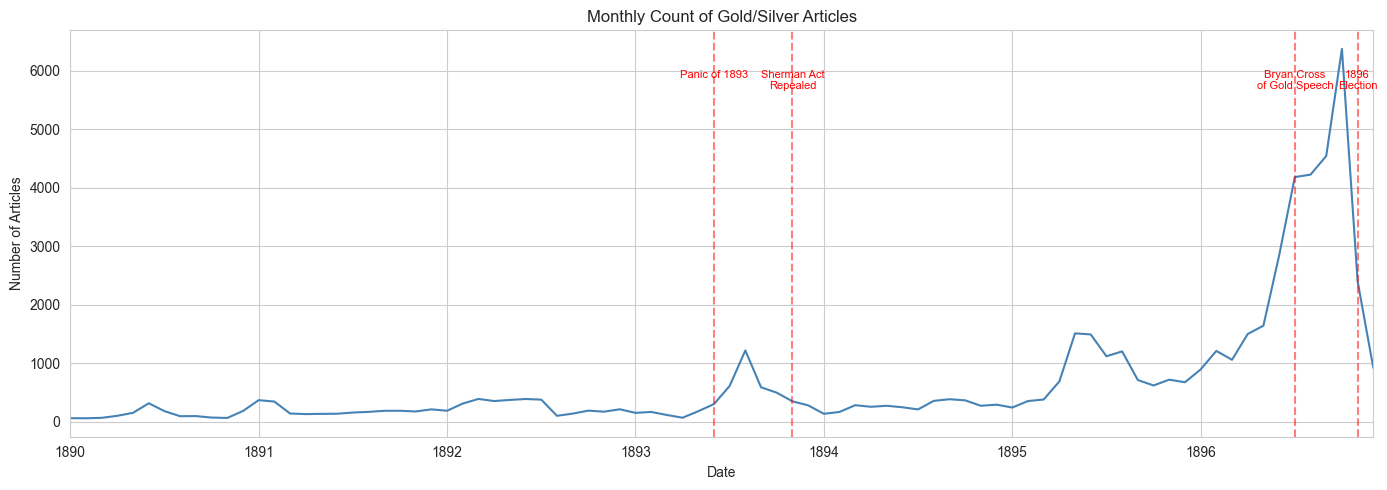

In [6]:
# Try to parse dates for finer-grained time series
df['date_parsed'] = pd.to_datetime(df['date'], errors='coerce')
valid_dates = df.dropna(subset=['date_parsed'])

if len(valid_dates) > 0:
    monthly = valid_dates.set_index('date_parsed').resample('ME').size()
    
    fig, ax = plt.subplots(figsize=(14, 5))
    monthly.plot(ax=ax, color='steelblue')
    ax.set_xlabel('Date')
    ax.set_ylabel('Number of Articles')
    ax.set_title('Monthly Count of Gold/Silver Articles')
    
    # Mark key events
    events = {
        '1893-06-01': 'Panic of 1893',
        '1893-11-01': 'Sherman Act\nRepealed',
        '1896-07-01': 'Bryan Cross\nof Gold Speech',
        '1896-11-01': '1896\nElection',
    }
    for date_str, label in events.items():
        ax.axvline(pd.Timestamp(date_str), color='red', linestyle='--', alpha=0.5)
        ax.text(pd.Timestamp(date_str), ax.get_ylim()[1] * 0.9, label,
                ha='center', va='top', fontsize=8, color='red')
    
    plt.tight_layout()
    plt.show()
else:
    print("Could not parse dates. Check date format in the data.")

## Keyword Frequency

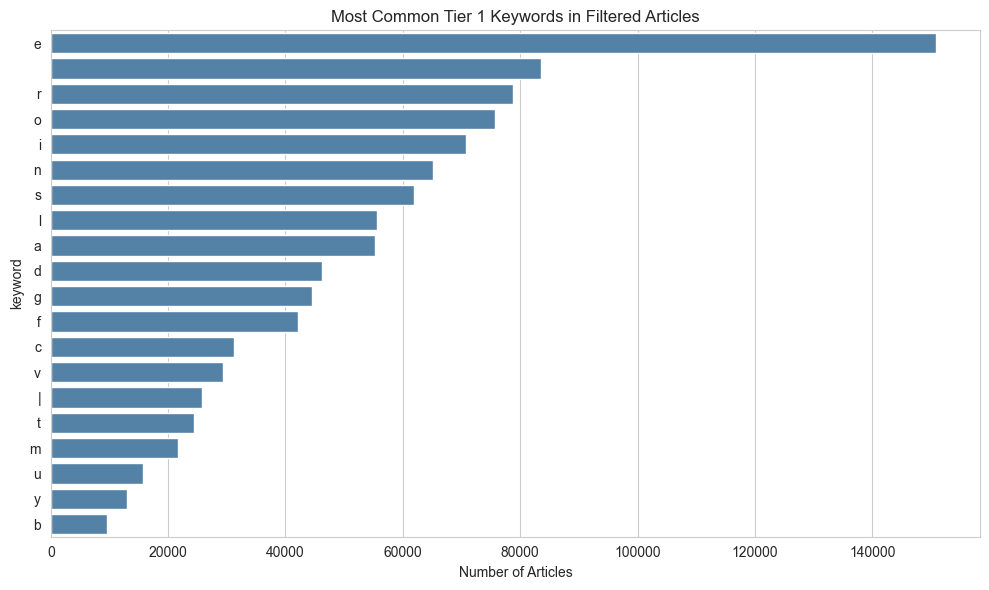

In [7]:
# Most common keywords across all articles
all_kw = [kw for kw_list in df['matched_keywords'] for kw in kw_list]
kw_counts = Counter(all_kw).most_common(20)

kw_df = pd.DataFrame(kw_counts, columns=['keyword', 'count'])

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=kw_df, y='keyword', x='count', ax=ax, color='steelblue')
ax.set_title('Most Common Tier 1 Keywords in Filtered Articles')
ax.set_xlabel('Number of Articles')
plt.tight_layout()
plt.show()

## Top Newspapers

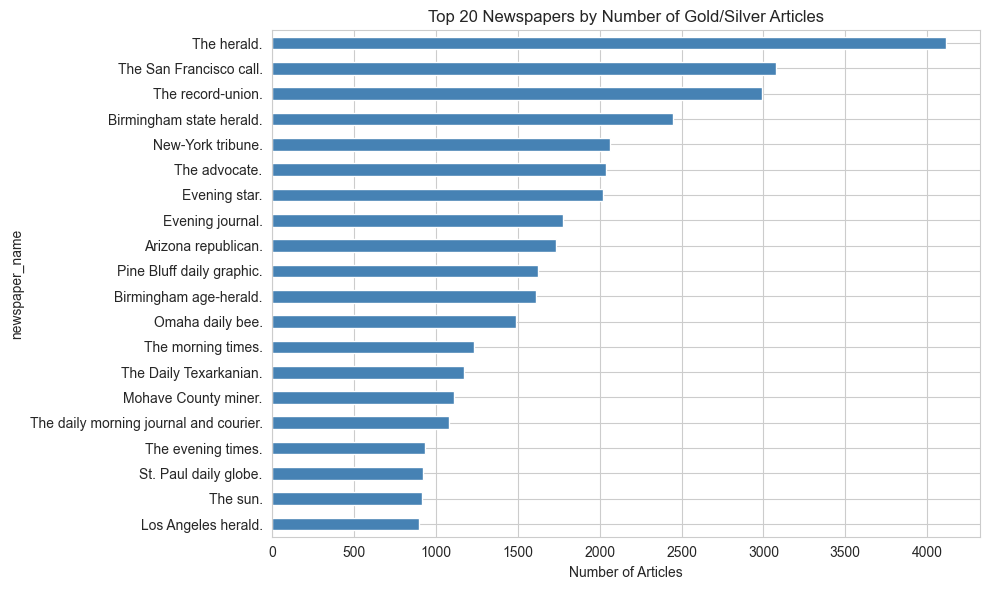

In [8]:
# Most represented newspapers
top_papers = df['newspaper_name'].value_counts().head(20)

fig, ax = plt.subplots(figsize=(10, 6))
top_papers.plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Number of Articles')
ax.set_title('Top 20 Newspapers by Number of Gold/Silver Articles')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## Sample Articles

Let's read a few articles to get a qualitative sense of the data.

In [9]:
# Show 3 random articles
sample_articles = df.sample(min(3, len(df)), random_state=42)

for i, (_, row) in enumerate(sample_articles.iterrows()):
    print(f"{'='*80}")
    print(f"ARTICLE {i+1}")
    print(f"Newspaper: {row['newspaper_name']}")
    print(f"Date: {row['date']}")
    print(f"Headline: {row['headline']}")
    print(f"Keywords matched: {row['matched_keywords']}")
    print(f"\n{row['article'][:1000]}")
    if len(row['article']) > 1000:
        print(f"\n... [{len(row['article']) - 1000} more characters]")
    print()

ARTICLE 1
Newspaper: Los Angeles herald.
Date: 1892-10-28
Headline: HILL wHOOPING 1T UP.

The Senator Addresses Large Crowds al


Lynchburg, Va.
Keywords matched: currency question

The Senator Addresses Large Crowds at


Lynchburg, Va.


LYNcHBURG. Va, Oct. Ex-senator
David B. Hill of New York talked
Democracy and reform to an admiring
multitude in this city, this afternoon
and this evening. He was at the In
dustrial Society fair in the afternoon,
and talked to an immense gathering of
workingmen and farmers. This evening
he was. the center of attraction at
Democratic rally.


In his speech tonight, Sem
ator Hill, after dealing at
length with the tariff and other
questions. made plea for the return
Of the third party men to the Democratic
party. They agreed with the Demo-
Gratis. he said, in opposition to high
tariff, TO the Capitalization OF power in
the general government, and in main
upon the great questions of currency.
He had no word of censure for those who
went honestly into tha

## Data Quality Checks

In [10]:
# Missing values
print("Missing values:")
print(df.isnull().sum())
print(f"\nEmpty article text: {(df['article'].str.len() == 0).sum()}")
print(f"Empty newspaper_name: {(df['newspaper_name'].str.len() == 0).sum()}")
print(f"Empty LCCN: {(df['lccn'].str.len() == 0).sum()}")

Missing values:
article_id          0
newspaper_name      0
edition             0
date                0
page                0
headline            0
byline              0
article             0
lccn                0
year                0
matched_keywords    0
article_length      0
n_keywords          0
date_parsed         0
dtype: int64

Empty article text: 0
Empty newspaper_name: 0
Empty LCCN: 82


In [11]:
# Check for potential OCR noise: articles that are very short or repetitive
print(f"Articles < 200 chars: {(df['article_length'] < 200).sum()}")
print(f"Articles < 500 chars: {(df['article_length'] < 500).sum()}")
print(f"Articles > 5000 chars: {(df['article_length'] > 5000).sum()}")

Articles < 200 chars: 2545
Articles < 500 chars: 10779
Articles > 5000 chars: 6283


## Save Timeline Figure for README

Saved to ../figures/timeline_banner.png


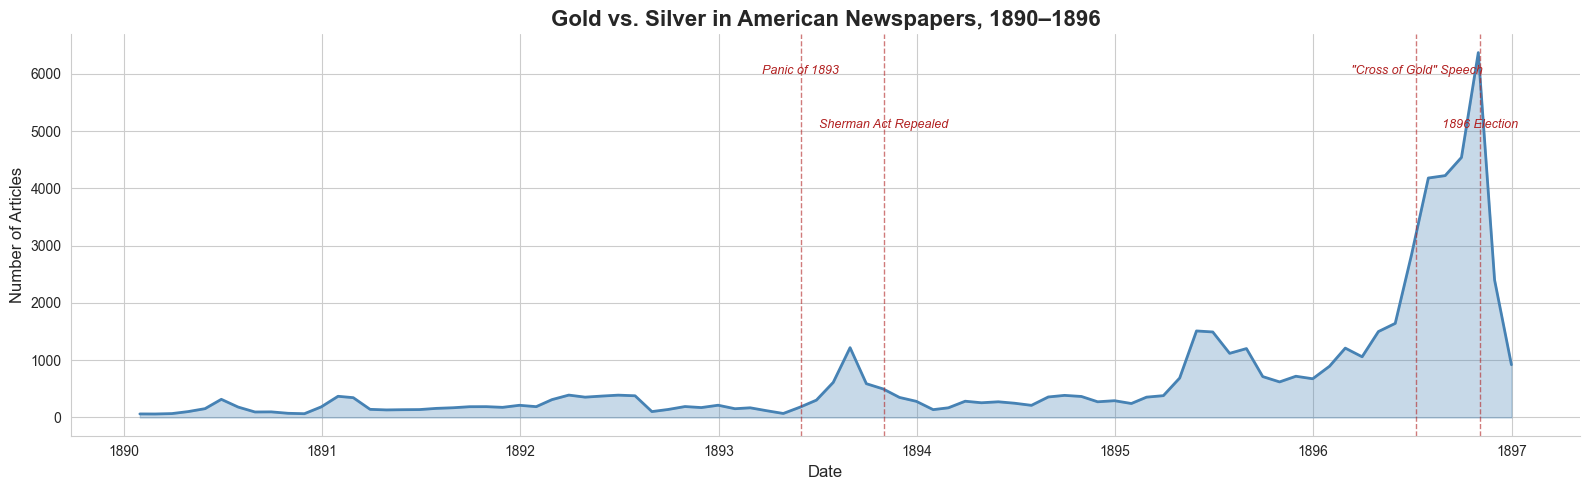

In [12]:
# Recreate the monthly timeline as a polished banner image for the README
fig, ax = plt.subplots(figsize=(16, 5))

monthly = valid_dates.set_index('date_parsed').resample('ME').size()
ax.fill_between(monthly.index, monthly.values, alpha=0.3, color='steelblue')
ax.plot(monthly.index, monthly.values, color='steelblue', linewidth=2)

ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Number of Articles', fontsize=12)
ax.set_title('Gold vs. Silver in American Newspapers, 1890–1896', fontsize=16, fontweight='bold')

# Mark key events with cleaner styling
events = {
    '1893-06-01': ('Panic of 1893', 0.92),
    '1893-11-01': ('Sherman Act Repealed', 0.78),
    '1896-07-09': ('"Cross of Gold" Speech', 0.92),
    '1896-11-03': ('1896 Election', 0.78),
}
for date_str, (label, y_frac) in events.items():
    ax.axvline(pd.Timestamp(date_str), color='firebrick', linestyle='--', alpha=0.6, linewidth=1)
    ax.text(pd.Timestamp(date_str), ax.get_ylim()[1] * y_frac, label,
            ha='center', va='top', fontsize=9, color='firebrick', fontstyle='italic')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()

save_path = "../figures/timeline_banner.png"
import os
os.makedirs(os.path.dirname(save_path), exist_ok=True)
fig.savefig(save_path, dpi=200, bbox_inches='tight', facecolor='white')
print(f"Saved to {save_path}")
plt.show()